# 04. Review

최종 제출 모델의 OOF 성능을 기준으로 평가 분석에 사용할 표와 시각화를 생성합니다.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.model_selection import StratifiedKFold

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
SUB_DIR = ROOT / "submission"

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = "AppleGothic"

## 1. OOF prediction 로드

In [2]:
y = pd.read_csv(DATA_DIR / "y_train.csv").iloc[:, 0].astype(int).values
X = pd.read_csv(DATA_DIR / "X_train.csv")

def load_oof(cache_dir, name):
    return np.load(SUB_DIR / cache_dir / f"{name}_oof.npy")

def rank01(values):
    return pd.Series(values).rank(method="average").to_numpy() / len(values)

compact = load_oof("oof_cache_daylong", "compact_regularized_enc")
lgbm72 = load_oof("oof_cache_final", "lgbm72")
raw_d8 = load_oof("oof_cache_raw_catboost", "depth8_conservative")
raw_d7 = load_oof("oof_cache_raw_catboost", "base_depth7")
fc80 = load_oof("oof_cache_feature_count_sweep", "review_exact_nf80_5seed")

final_oof = 0.25 * compact + 0.35 * lgbm72 + 0.30 * raw_d8 + 0.10 * raw_d7
review_oof = 0.30 * compact + 0.32 * lgbm72 + 0.38 * raw_d8
rank_oof = 0.20 * rank01(compact) + 0.28 * rank01(lgbm72) + 0.38 * rank01(raw_d8) + 0.14 * rank01(raw_d7)
meta_oof = 0.85 * final_oof + 0.05 * review_oof + 0.10 * rank_oof

seg_oof = meta_oof.copy()
seg_oof[X["배아 이식 경과일"].eq(1.0).values] = lgbm72[X["배아 이식 경과일"].eq(1.0).values]
mask = X["배아 이식 경과일"].eq(5.0).values
seg_oof[mask] = 0.40 * final_oof[mask] + 0.60 * meta_oof[mask]
mask = X["is_eset"].eq(1.0).values
seg_oof[mask] = 0.45 * compact[mask] + 0.55 * seg_oof[mask]
mask = X["이식된 배아 수"].eq(3.0).values
seg_oof[mask] = raw_d7[mask]

feature_sweep_oof = 0.40 * fc80 + 0.25 * compact + 0.35 * raw_d8
final_blend_oof = 0.76 * seg_oof + 0.14 * fc80 + 0.10 * feature_sweep_oof

models = {
    "Compact LGBM Optuna blend": compact,
    "LGBM review 72 feature": lgbm72,
    "Raw CatBoost depth8": raw_d8,
    "Raw CatBoost depth7": raw_d7,
    "Feature-count sweep blend": feature_sweep_oof,
    "Conservative segment blend": seg_oof,
    "Final blend with feature-count": final_blend_oof,
}

score_board = pd.DataFrame({
    "model": list(models),
    "oof_auc": [roc_auc_score(y, pred) for pred in models.values()],
}).sort_values("oof_auc", ascending=False)

score_board

,model,oof_auc
6,final_blend,0.740928
5,segment_blend,0.740921
4,feature_sweep,0.740894
0,compact_lgbm,0.740727
1,lgbm72,0.740721
2,raw_cat_d8,0.740605
3,raw_cat_d7,0.740592


## 2. 모델별 OOF AUC 비교

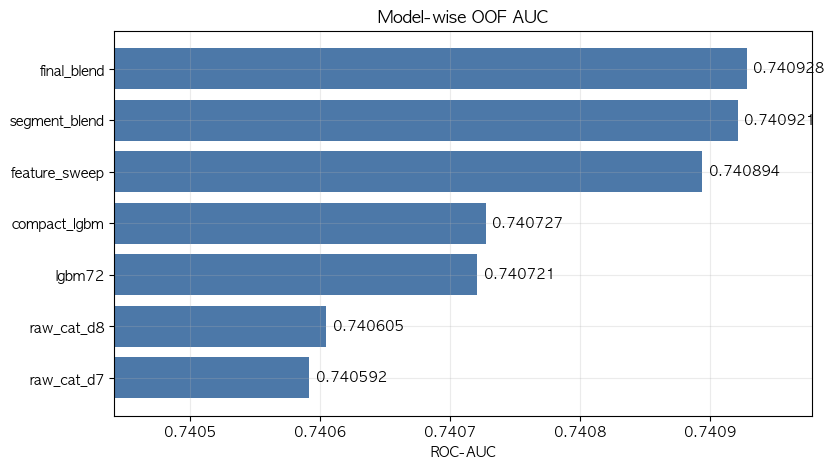

In [10]:
plot_df = score_board.sort_values("oof_auc")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["model"], plot_df["oof_auc"], color="#4C78A8")
ax.set_xlim(plot_df["oof_auc"].min() - 0.00015, plot_df["oof_auc"].max() + 0.00005)
ax.set_title("Model-wise OOF AUC")
ax.set_xlabel("ROC-AUC")

for i, v in enumerate(plot_df["oof_auc"]):
    ax.text(v + 0.000005, i, f"{v:.6f}", va="center")

plt.show()

## 3. 최종 OOF ROC Curve

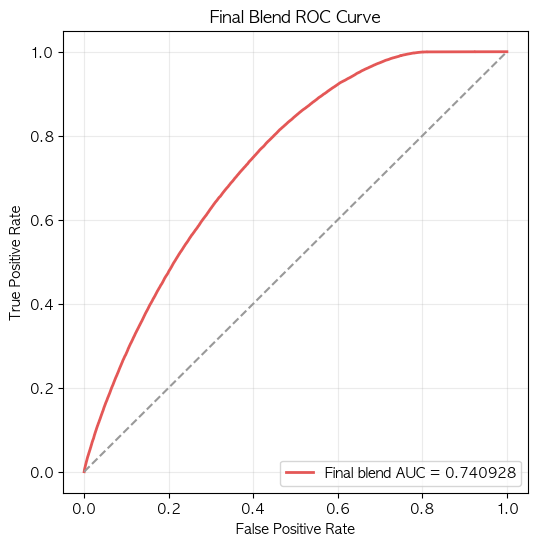

In [4]:
fpr, tpr, _ = roc_curve(y, final_blend_oof)
roc_value = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, label=f"Final blend AUC = {roc_value:.6f}", color="#E45756", linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="#999999")
ax.set_title("Final Blend ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.show()

## 4. Fold별 OOF AUC 안정성

,fold,auc
0,1,0.738872
1,2,0.743704
2,3,0.741409
3,4,0.738940
4,5,0.741730


mean: 0.7409308641735612 std: 0.0020470963710040807


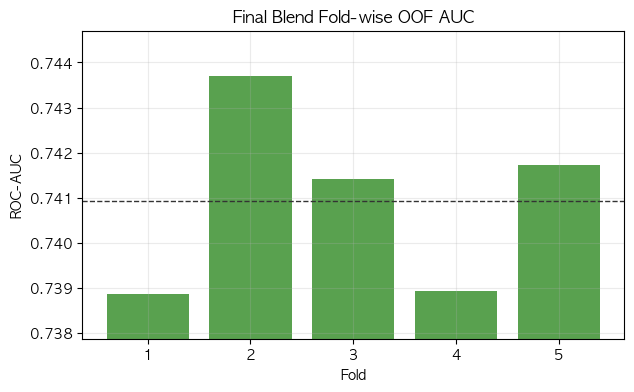

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []

for fold, (_, valid_idx) in enumerate(skf.split(X, y), start=1):
    fold_scores.append({
        "fold": fold,
        "auc": roc_auc_score(y[valid_idx], final_blend_oof[valid_idx]),
    })

fold_df = pd.DataFrame(fold_scores)
display(fold_df)
print("mean:", fold_df["auc"].mean(), "std:", fold_df["auc"].std())

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(fold_df["fold"].astype(str), fold_df["auc"], color="#59A14F")
ax.axhline(fold_df["auc"].mean(), color="#333333", linestyle="--", linewidth=1)
ax.set_ylim(fold_df["auc"].min() - 0.001, fold_df["auc"].max() + 0.001)
ax.set_title("Final Blend Fold-wise OOF AUC")
ax.set_xlabel("Fold")
ax.set_ylabel("ROC-AUC")
plt.show()

## 5. Segment별 취약 구간 확인

,feature,value,n,target_mean,auc
36,배아 이식 경과일,1.0,6053,0.187015,0.612505
43,포배기_이식,1.0,81459,0.404449,0.619661
40,배아 이식 경과일,5.0,81459,0.404449,0.619661
41,배아 이식 경과일,6.0,2773,0.300036,0.622056
45,장기배양_이식,1.0,88826,0.398149,0.622969
39,배아 이식 경과일,4.0,4504,0.344361,0.624325
13,배아 생성 주요 이유,9.0,9192,0.000870,0.633330
49,is_eset,1.0,58383,0.367230,0.634501
47,is_blastocyst,1.0,2868,0.360879,0.654844
33,이식된 배아 수,2.0,110845,0.311092,0.656336


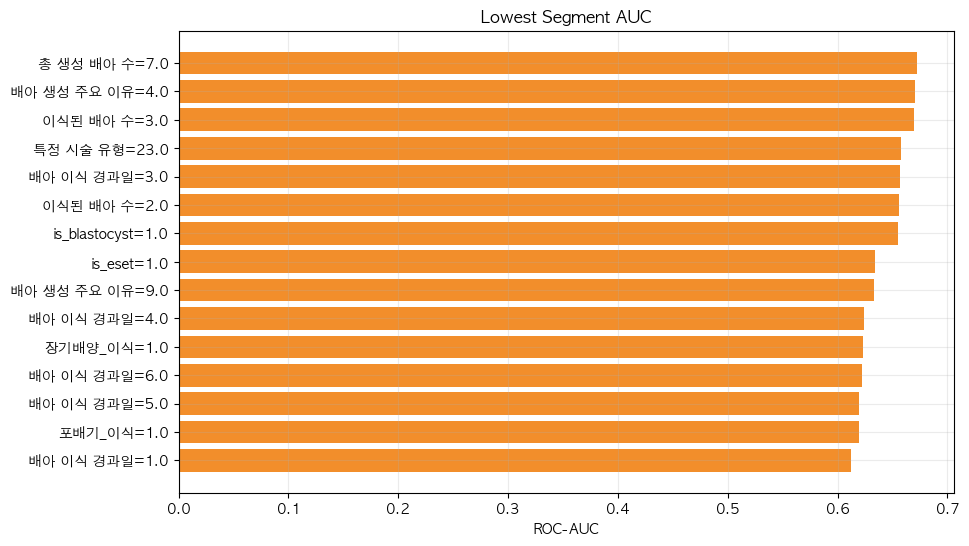

In [6]:
segment_cols = [
    "시술 유형", "특정 시술 유형", "시술 당시 나이", "배아 생성 주요 이유",
    "총 생성 배아 수", "이식된 배아 수", "배아 이식 경과일",
    "포배기_이식", "장기배양_이식", "is_blastocyst", "is_eset", "기증_난자",
]

rows = []
min_n = 2500
for col in segment_cols:
    if col not in X.columns:
        continue
    for value, idx in X.groupby(col, dropna=False).groups.items():
        idx = np.asarray(list(idx))
        if len(idx) < min_n or len(np.unique(y[idx])) < 2:
            continue
        rows.append({
            "feature": col,
            "value": value,
            "n": len(idx),
            "target_mean": y[idx].mean(),
            "auc": roc_auc_score(y[idx], final_blend_oof[idx]),
        })

segment_df = pd.DataFrame(rows).sort_values("auc")
display(segment_df.head(20))

plot_df = segment_df.head(15).copy()
plot_df["segment"] = plot_df["feature"].astype(str) + "=" + plot_df["value"].astype(str)
plot_df = plot_df.sort_values("auc")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["segment"], plot_df["auc"], color="#F28E2B")
ax.set_title("Lowest Segment AUC")
ax.set_xlabel("ROC-AUC")
plt.show()

## 6. Feature Importance Top 20

,feature,importance
0,시술 시기 코드_te,625.2
1,배아_활용률,571.4
2,배아생성_능력,532.6
3,난자_배아_전환율,528.8
4,성숙_난자율,516.8
5,이식된 배아 수,478.6
6,혼합난자_배아효율,478.4
7,실효_난자나이,474.2
8,시술 당시 나이,434.0
9,배아_저장비율,401.6


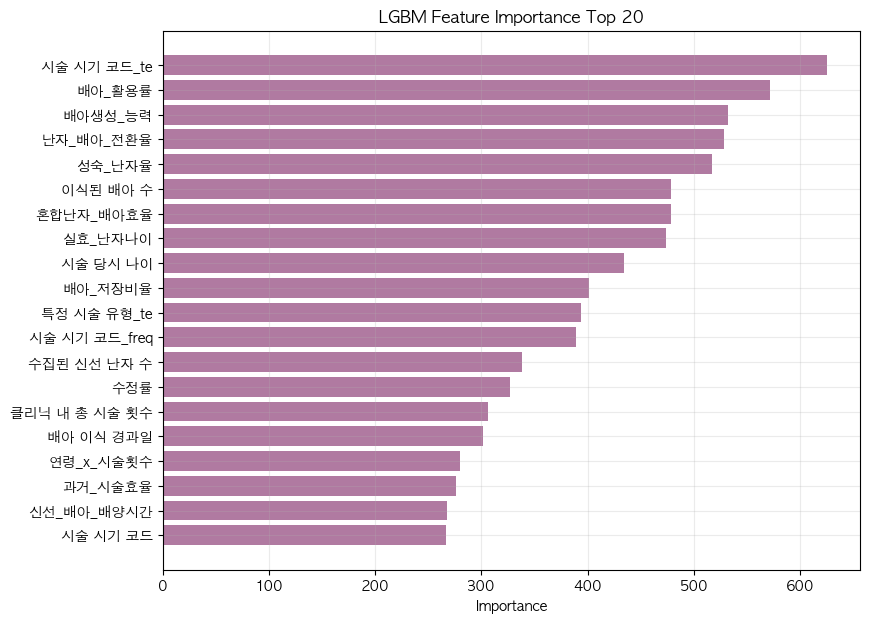

In [7]:
importance_files = sorted(SUB_DIR.glob("lgbm_review72_importance_*.csv"))
if not importance_files:
    raise FileNotFoundError("lgbm_review72_importance_*.csv 파일이 없습니다.")

imp = pd.read_csv(importance_files[-1]).sort_values("importance", ascending=False).head(20)
display(imp)

plot_df = imp.sort_values("importance")
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(plot_df["feature"], plot_df["importance"], color="#B07AA1")
ax.set_title("LGBM Feature Importance Top 20")
ax.set_xlabel("Importance")
plt.show()

## 7. 최종 Blend 구성

,source,weight
0,segment_blend,0.76
1,feature_count_nf80,0.14
2,feature_sweep_blend,0.10


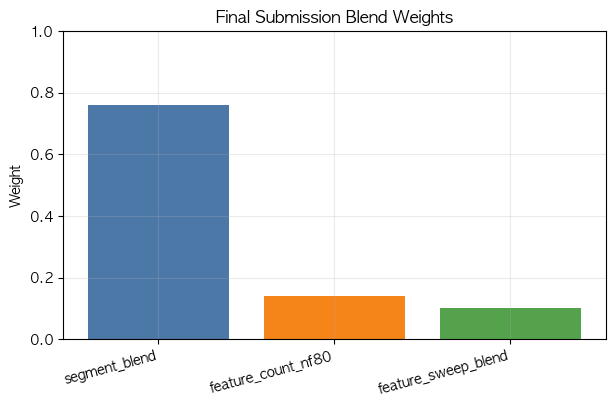

final_blend_oof_auc: 0.7409284668202374
public_score: 0.742116375


In [8]:
blend_df = pd.DataFrame({
    "source": ["segment_blend", "feature_count_nf80", "feature_sweep_blend"],
    "weight": [0.76, 0.14, 0.10],
})

display(blend_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(blend_df["source"], blend_df["weight"], color=["#4C78A8", "#F58518", "#54A24B"])
ax.set_ylim(0, 1)
ax.set_title("Final Submission Blend Weights")
ax.set_ylabel("Weight")
plt.xticks(rotation=15, ha="right")
plt.show()

print("final_blend_oof_auc:", roc_auc_score(y, final_blend_oof))
print("public_score:", 0.742116375)